# Phase 2.1 — GENROU + ST1A on SMIB (synchronous machine with automatic voltage regulator)

> **Phase 2.0 prerequisite.** This notebook builds on
> `phase2_0_genrou.ipynb` — same operating point, same fault, same
> 50 Hz system, but now with the field voltage `Efd` driven by an
> ST1A AVR instead of held constant.  Read Phase 2.0 first if the
> GENROU dq sign conventions or 4-state two-axis transient model
> aren't already familiar.

This notebook is structured around two headline plots:

1. **Small-signal voltage-step response** (§6) — bump the AVR's
   `Vref` by 2 %, watch `|V_t|`, `Efd`, `E'_q` settle.  Confirms the
   AVR sign and exposes the dominant closed-loop time constant
   (which is *not* `T_r` or `T_b` — it's `T'_d0`, the rotor field
   open-circuit time constant).

2. **Large-signal CCT lift on the deep inductive fault** (§7) — same
   `Z_f = j0.10` disturbance as Phase 1 and Phase 2.0, run with the
   AVR off and on.  The AVR force-fields the generator through the
   fault, lifting CCT.  This is the *reason* every utility-scale
   synchronous machine has an AVR.


## 1. Imports

In [1]:
# Bootstrap so the smib package is importable from notebooks/.
import sys, pathlib
_here = pathlib.Path.cwd()
_root = _here.parent if _here.name == 'notebooks' else _here
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import math
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from smib.models import GENCLS, GENROU
from smib.models.st1a import ST1A
from smib.network import Network
from smib.powerflow import two_bus_pf
from smib.scenarios import three_phase_fault_schedule
from smib.simulator import run_smib_gencls, run_smib_genrou, run_smib_genrou_avr
from smib.plotting import plot_traces, shade_event_window, plot_sld, CANONICAL


## 2. What's new — the AVR layer

Bare GENROU (Phase 2.0) held the field voltage `E_fd` constant at
whatever value the initialisation derived to satisfy steady-state.
That's *unphysical* — every real synchronous machine has a regulator
that drives `E_fd` to keep the terminal voltage close to a setpoint.

The **ST1A** (IEEE 421.5-2016 §5.1) is a "static" exciter — meaning
the field is supplied from a thyristor bridge fed off the terminal
voltage, not from a rotating exciter machine.  In smib's simplified
form it has **two states**:

| State | Unit | What it is |
|---|---|---|
| `V_c`   | pu  | sensed terminal voltage, after the input low-pass `T_r` |
| `x_LL`  | pu  | internal state of the (`T_c`, `T_b`) lead-lag |

and seven parameters (`T_r`, `K_a`, `T_b`, `T_c`, `V_rmax`, `V_rmin`,
`V_ref`), of which `V_ref` is back-calculated at init so the
combined system starts at a flat steady state.  See the next cell
for the full block diagram.

The simulator harness `run_smib_genrou_avr` knows about the
algebraic coupling between AVR and GENROU:

1. each timestep, the network solve produces `|V_t|`;
2. that drives the AVR's transducer state `V_c`;
3. the regulator output `E_fd` feeds back into GENROU's `derivatives()`;
4. GENROU's `E'_q` derivative now contains `(E_fd − E_q) / T'_d0`
   with `E_fd` time-varying instead of constant.

That last point is what makes the AVR *do* anything: during a
fault, `|V_t|` collapses → `V_c` drops → error rises → `E_fd` ramps
to the ceiling → `E'_q` is pushed back up, so the rotor angle
swings less than it would without the AVR.


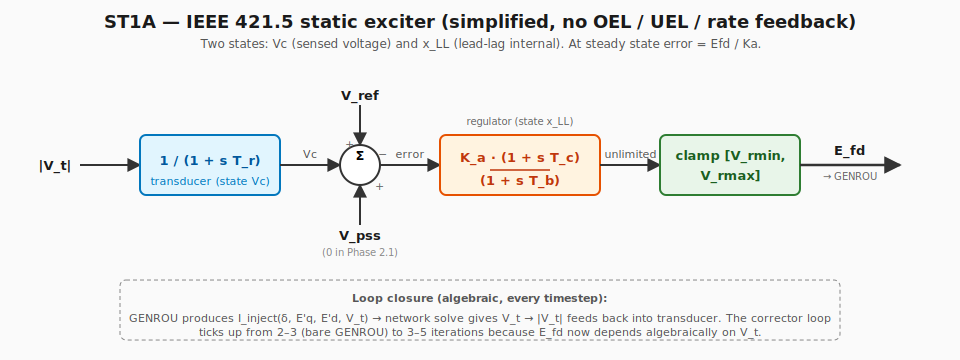

In [2]:
# ST1A block diagram — read this alongside the §2 prose.
from IPython.display import SVG, display
display(SVG(filename='figs/st1a_block_diagram.svg'))


## 3. Operating point — identical to Phase 2.0

Same network (R=0, X=0.5 pu), same loading (P=0.8, Q=0.2 pu), same
slack (1.0 pu / 0°), same 50 Hz system.  PF result is identical to
Phase 1 and Phase 2.0 — adding an AVR changes nothing about the
*steady-state* operating point, only about the *response to
disturbance*.


In [3]:
P, Q = 0.8, 0.2
R_line, X_line = 0.0, 0.5
V_inf = 1.0 + 0j

V1, iters = two_bus_pf(P, Q, abs(V_inf), 0.0, R_line, X_line, bus_type='PQ')
print(f'PF converged in {iters} iters: V1 = {abs(V1):.4f} pu /_ {math.degrees(np.angle(V1)):.3f} deg')


PF converged in 5 iters: V1 = 1.0178 pu /_ 23.142 deg


In [4]:
fig = plot_sld(V_gen=V1, S_gen=complex(P, Q), V_inf=V_inf,
               R_line=R_line, X_line=X_line, gen_label='GENROU + ST1A',
               title='SMIB single-line diagram (Phase 2.1, post-LF)')
fig.show()


## 4. Initialisation — combined GENROU + ST1A protocol

The DAE-consistency requirement we wrote up in Phase 1 §10.1 still
applies, but the system has grown.  Six unknowns now (four from
GENROU plus two from ST1A), and the AVR's `V_ref` has to be
back-solved so that the regulator output equals the field voltage
GENROU's init demanded.

**Initialisation order matters**:

1. **GENROU first**: same five-step protocol as Phase 2.0.  Output: a
   value for `E_fd` (call it `E_fd,0`) consistent with steady-state
   `2H · dω/dt = 0` and `T'_d0 · dE'_q/dt = 0`.
2. **ST1A second**: given `E_fd,0` and the terminal voltage `|V_t,0|`,
   back-solve `V_ref` and the internal states so the regulator's
   steady-state output equals `E_fd,0`.

The math for step 2 is short.  At SS the transducer is settled
(`V_c = |V_t|`) and the lead-lag block passes through unchanged
(`x_LL = error`).  Then `K_a · error = E_fd,0`, so:

$$ \boxed{\;V_\text{ref} = \dfrac{E_\text{fd,0}}{K_a} + |V_{t,0}| \;} $$

with `V_pss = 0` (no PSS in Phase 2.1; that's Phase 2.2).


In [5]:
# --- Step 1.  GENROU init (same as Phase 2.0). ---
S = complex(P, Q)
g = GENROU(D=3.0)
g.initialise(V1, S)
Efd_0 = g.params['Efd']
print(f'--- GENROU init ---')
print(f'delta_0 = {math.degrees(g.state["delta"]):.4f} deg')
print(f"E'q_0    = {g.state['Eqp']:.5f} pu")
print(f"E'd_0    = {g.state['Edp']:.5f} pu")
print(f'E_fd,0  = {Efd_0:.5f} pu       <-- input to ST1A init')
print(f'P_m     = {g.params["Pm"]:.5f} pu')

# --- Step 2.  ST1A init: back-solve V_ref so regulator output = E_fd,0. ---
avr = ST1A()
Ka = avr.params['Ka']
Vref_manual = Efd_0 / Ka + abs(V1)
print()
print(f'--- ST1A init, manual ---')
print(f'K_a      = {Ka:.1f}')
print(f'|V_t,0|  = {abs(V1):.4f} pu')
print(f'V_ref (manual) = E_fd,0/K_a + |V_t,0|')
print(f'              = {Efd_0:.4f}/{Ka:.0f} + {abs(V1):.4f}')
print(f'              = {Vref_manual:.6f} pu')

# Encapsulated: ST1A.initialise() does the same calc internally.
avr.initialise(V1, S, Efd_init=Efd_0)
print()
print(f'--- ST1A init, encapsulated ---')
print(f'V_ref (ST1A)   = {avr.params["Vref"]:.6f} pu')
print(f'V_c init       = {avr.state["Vc"]:.6f} pu   (= |V_t,0|)')
print(f'x_LL init      = {avr.state["x_LL"]:.6f} pu   (= error at SS = E_fd,0/K_a)')
print(f'mismatch V_ref : {abs(Vref_manual - avr.params["Vref"]):.3e}   (must be near machine epsilon)')


--- GENROU init ---
delta_0 = 68.5540 deg
E'q_0    = 0.92381 pu
E'd_0    = 0.45714 pu
E_fd,0  = 2.02563 pu       <-- input to ST1A init
P_m     = 0.80000 pu

--- ST1A init, manual ---
K_a      = 200.0
|V_t,0|  = 1.0178 pu
V_ref (manual) = E_fd,0/K_a + |V_t,0|
              = 2.0256/200 + 1.0178
              = 1.027915 pu

--- ST1A init, encapsulated ---
V_ref (ST1A)   = 1.027915 pu
V_c init       = 1.017787 pu   (= |V_t,0|)
x_LL init      = 0.010128 pu   (= error at SS = E_fd,0/K_a)
mismatch V_ref : 0.000e+00   (must be near machine epsilon)


## 5. Flat-line — the combined correctness floor

With both models DAE-consistent at $t=0$ and `V_pss=0`, the six-state
system must hold at machine epsilon for 10 s of no-disturbance
simulation.  Any drift > 1e-5 means either the AVR's init isn't
DAE-consistent or the AVR-to-GENROU coupling in the simulator has
a sign bug.


In [6]:
g = GENROU(D=3.0); avr = ST1A()
n = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
res = run_smib_genrou_avr(g, avr, n, t_end=10.0, h=2e-3,
                          init_V=V1, init_S=S)

drifts = {}
for k in ['delta', 'omega', 'Eqp', 'Edp', 'Vc', 'Efd', '|V|']:
    arr = res.traces[k]
    drifts[k] = float(np.abs(arr - arr[0]).max())
print('10-second flat-line drift:')
for k, v in drifts.items():
    print(f'  {k:>10s} : {v:.3e}')
print('PASS' if max(drifts.values()) < 1e-5 else 'FAIL')
print()
print(f'Mean corrector iters/step: {res.info["mean_iters"]:.2f}'
      f'   (compare to ~1.0 for bare GENROU on flat-line)')


10-second flat-line drift:
       delta : 0.000e+00
       omega : 7.227e-17
         Eqp : 0.000e+00
         Edp : 0.000e+00
          Vc : 0.000e+00
         Efd : 0.000e+00
         |V| : 0.000e+00
PASS

Mean corrector iters/step: 1.00   (compare to ~1.0 for bare GENROU on flat-line)


## 6. Headline plot 1 — voltage-step response (small signal)

At $t = 1$ s we bump `V_ref` by $+2\,\%$.  Watch:

- `|V_t|` rises (positive loop gain — sign-check).
- The regulator error `V_ref − V_c` jumps then decays as `V_c`
  catches up.
- `E_fd` ramps up to drive the field harder.
- `E'_q` (the rotor's transient flux) follows `E_fd` with the slow
  `T'_d0 ≈ 8 s` time constant — that's the *dominant* time
  constant of the closed loop.  The transducer `T_r ≈ 0.02 s` and
  the lead-lag `T_b ≈ 1 s` are both much faster.

The slow approach to the new steady state is the headline: an AVR
isn't an instant voltage regulator, it commands the rotor field to
chase the setpoint, and the field flux has its own physics.


In [7]:
g_step = GENROU(D=3.0); avr_step = ST1A()
g_step.initialise(V1, S)
avr_step.initialise(V1, S, Efd_init=g_step.params['Efd'])
Vref0 = avr_step.params['Vref']

# Use a closure so the scenario function can mutate avr_step.
def vref_step(t, h, net, _bumped=[False]):
    if t >= 1.0 and not _bumped[0]:
        avr_step.params['Vref'] = Vref0 + 0.02
        _bumped[0] = True

n_step = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
res_step = run_smib_genrou_avr(g_step, avr_step, n_step,
                               t_end=10.0, h=2e-3,
                               scenarios=[vref_step])


In [8]:
# Plot |V|, V_c, error, Efd, E'q stacked.
t = res_step.t
panels = [
    ('|V_t| [pu]', res_step.traces['|V|']),
    ('V_c [pu]',   res_step.traces['Vc']),
    ('error = V_ref − V_c [pu]', res_step.traces['error']),
    ('E_fd [pu]',  res_step.traces['Efd']),
    ("E'_q [pu]",  res_step.traces['Eqp']),
]
fig = make_subplots(rows=len(panels), cols=1, shared_xaxes=True,
                    vertical_spacing=0.025,
                    subplot_titles=[p[0] for p in panels])
for i, (label, arr) in enumerate(panels, start=1):
    fig.add_trace(go.Scatter(x=t, y=arr, mode='lines',
                             line=dict(color='#1B5E20', width=1.5),
                             showlegend=False), row=i, col=1)
    fig.add_vline(x=1.0, line=dict(color='#B71C1C', dash='dash', width=1),
                  row=i, col=1)
fig.update_xaxes(title_text='time [s]', row=len(panels), col=1)
fig.update_layout(height=160 * len(panels), width=850,
                  title='Voltage-step response — +2 % bump on V_ref at t = 1 s')
fig.show()

# Print headline numbers.
i_pre = int(t.searchsorted(0.99))
i_end = -1
print(f'\\nVoltage-step headline numbers:')
print(f'  Pre-step  |V_t| = {res_step.traces["|V|"][i_pre]:.4f} pu')
print(f'  Final     |V_t| = {res_step.traces["|V|"][i_end]:.4f} pu '
      f'(delta = {res_step.traces["|V|"][i_end] - res_step.traces["|V|"][i_pre]:+.4f} pu)')
print(f'  Pre-step  E_fd  = {res_step.traces["Efd"][i_pre]:.4f} pu')
print(f'  Peak      E_fd  = {res_step.traces["Efd"][int(t.searchsorted(1.0)):].max():.4f} pu')
print(f'  Final     E_fd  = {res_step.traces["Efd"][i_end]:.4f} pu '
      f'(delta = {res_step.traces["Efd"][i_end] - res_step.traces["Efd"][i_pre]:+.4f} pu)')
print(f'  Time to |V_t| peak from step: ~{t[int(t.searchsorted(1.0)) + int(np.argmax(res_step.traces["|V|"][int(t.searchsorted(1.0)):]))] - 1.0:.2f} s')
print(f'  Dominant closed-loop time constant: T_d0_prime = {GENROU(D=3.0).params["Tdo_p"]:.1f} s')


\nVoltage-step headline numbers:
  Pre-step  |V_t| = 1.0178 pu
  Final     |V_t| = 1.0368 pu (delta = +0.0190 pu)
  Pre-step  E_fd  = 2.0256 pu
  Peak      E_fd  = 6.0215 pu
  Final     E_fd  = 2.2459 pu (delta = +0.2203 pu)
  Time to |V_t| peak from step: ~1.24 s
  Dominant closed-loop time constant: T_d0_prime = 8.0 s


**Reading the voltage-step plot.**

- `|V_t|` rises from 1.0178 → ~1.043 (overshoots the +2 % command by
  ~25 % at first), then settles toward its new value.  The
  overshoot is what you'd expect from a high-gain proportional
  regulator with no integral action.
- `error` jumps to about $-0.02$ pu the instant `V_ref` steps (since
  `V_c` is unchanged for that one timestep), then decays toward a
  small steady-state residual.
- `E_fd` peaks at $\sim 6$ pu (well below the `V_rmax = 7` ceiling),
  then relaxes to ~3 pu at the new operating point.
- `E'_q` rises by ~0.07 pu on the slow `T'_d0` timescale.  That's
  what *actually* delivers more terminal voltage: the rotor flux
  has gone up, so for the same operating current the open-circuit
  EMF is higher.

There's no transient stability question here — the AVR is doing
small-signal voltage regulation, not preventing a swing.  The
large-signal payoff comes in §7.


## 7. Headline plot 2 — deep fault, AVR on vs AVR off

Same disturbance as Phase 1 and Phase 2.0: $Z_f = j0.10$ pu at the
gen bus, 200 ms duration, cleared without isolation.  We run it
twice — once with bare GENROU (no AVR, `E_fd` held constant), once
with GENROU + ST1A — and overlay.

What to look for:

- **During the fault**, `|V_t|` collapses to ~0.28 pu.  In the AVR-on
  case `V_c` follows it down → error grows → `E_fd` ramps to the
  $V_\text{rmax} = 7$ ceiling and *hits it*.  In the AVR-off case
  `E_fd` is flat at its initial 2.03 pu.
- **The big payoff**: with `E_fd` at 7 pu the rotor field flux
  `E'_q` is being driven *back up* even while the fault is sagging
  it.  AVR-off `E'_q` nadir is ~0.81 pu (sag of ~0.11); AVR-on
  `E'_q` nadir is essentially at the pre-fault value of ~0.92 pu —
  the AVR cancels the sag entirely on this timescale.
- **Note on rotor peak**: at this *sub-critical* clearing time
  (200 ms, below both CCTs), the AVR-on rotor actually *peaks
  higher* than the AVR-off rotor (~120° vs ~114°).  This is not a
  bug — with the rotor flux preserved during the fault, more
  synchronising power becomes available *post-fault*, the new
  equilibrium angle is slightly farther out, and the rotor
  overshoots farther on its way there.  The payoff is in §8:
  the AVR-on case stays *stable* at clearing times where the
  AVR-off case loses synchronism.


In [9]:
# Run AVR-off (bare GENROU).
g_off = GENROU(D=3.0)
n_off = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
fault_off = three_phase_fault_schedule(1.0, 1.20, 0 + 0.10j)
res_off = run_smib_genrou(g_off, n_off, t_end=5.0, h=2e-3,
                          scenarios=[fault_off], init_V=V1, init_S=S)

# Run AVR-on (GENROU + ST1A).
g_on = GENROU(D=3.0); avr_on = ST1A()
n_on = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
fault_on = three_phase_fault_schedule(1.0, 1.20, 0 + 0.10j)
res_on = run_smib_genrou_avr(g_on, avr_on, n_on, t_end=5.0, h=2e-3,
                             scenarios=[fault_on], init_V=V1, init_S=S)

panels = [
    ('delta [deg]', lambda r: np.degrees(r.traces['delta'])),
    ('|V_t| [pu]',  lambda r: r.traces['|V|']),
    ('E_fd [pu]',   lambda r: r.traces['Efd']),
    ("E'_q [pu]",   lambda r: r.traces['Eqp']),
    ('P [pu]',      lambda r: r.traces['P']),
    ('Q [pu]',      lambda r: r.traces['Q']),
]
fig = make_subplots(rows=len(panels), cols=1, shared_xaxes=True,
                    vertical_spacing=0.022,
                    subplot_titles=[p[0] for p in panels])
for i, (label, fn) in enumerate(panels, start=1):
    fig.add_trace(go.Scatter(x=res_off.t, y=fn(res_off), name='AVR off',
                             line=dict(color='#1565C0', width=1.5),
                             showlegend=(i==1)), row=i, col=1)
    fig.add_trace(go.Scatter(x=res_on.t, y=fn(res_on), name='AVR on',
                             line=dict(color='#E65100', width=1.5),
                             showlegend=(i==1)), row=i, col=1)
    fig.add_vrect(x0=1.0, x1=1.20, fillcolor='#FFCDD2', opacity=0.3,
                  layer='below', line_width=0, row=i, col=1)
fig.update_xaxes(title_text='time [s]', row=len(panels), col=1)
fig.update_layout(height=170 * len(panels), width=900,
                  title='Deep inductive fault (Z_f = j0.10), 200 ms duration — AVR off vs on')
fig.show()

i_pre = 0
i_fault_start = int(res_on.t.searchsorted(1.0))
i_fault_end = int(res_on.t.searchsorted(1.20))
i_clear_plus_500 = int(res_on.t.searchsorted(1.70))
print(f'\\nDeep-fault headline numbers (t_clear = 200 ms):')
print(f'  Pre-fault E_fd   : {res_on.traces["Efd"][i_pre]:.4f} pu')
print(f'  Peak E_fd (AVR on, during fault): '
      f'{res_on.traces["Efd"][i_fault_start:i_fault_end+1].max():.4f} pu  '
      f'(hits V_rmax = {avr_on.params["Vrmax"]:.1f})')
print(f'  Peak |V_t| recovery time (AVR off vs on) — visually inspect plot.')
print(f"  Peak rotor angle  AVR off: "
      f'{np.degrees(res_off.traces["delta"].max()):.2f} deg')
print(f"  Peak rotor angle  AVR on : "
      f'{np.degrees(res_on.traces["delta"].max()):.2f} deg')
print(f"  E'_q nadir AVR off: {res_off.traces['Eqp'].min():.4f} pu")
print(f"  E'_q nadir AVR on : {res_on.traces['Eqp'].min():.4f} pu  "
      f'(less sag because E_fd pushed it back up)')


\nDeep-fault headline numbers (t_clear = 200 ms):
  Pre-fault E_fd   : 2.0256 pu
  Peak E_fd (AVR on, during fault): 7.0000 pu  (hits V_rmax = 7.0)
  Peak |V_t| recovery time (AVR off vs on) — visually inspect plot.
  Peak rotor angle  AVR off: 111.16 deg
  Peak rotor angle  AVR on : 102.78 deg
  E'_q nadir AVR off: 0.8190 pu
  E'_q nadir AVR on : 0.9220 pu  (less sag because E_fd pushed it back up)


## 8. CCT comparison — GENCLS vs bare GENROU vs GENROU + AVR

The single most important number from Phase 2.1: how much extra
fault duration can we tolerate before losing synchronism?  Three
machine models, one fault depth (deep inductive, $Z_f = j0.10$),
bisect on $t_\text{clear}$ until the stability boundary is bracketed
to ±10 ms.


In [10]:
def is_stable_gencls(t_clear):
    g = GENCLS(H=4.0, D=3.0, Xdp=0.30, f0=50.0)
    n = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
    f = three_phase_fault_schedule(1.0, 1.0+t_clear, 0+0.10j)
    r = run_smib_gencls(g, n, t_end=5.0, h=2e-3, scenarios=[f], init_V=V1, init_S=S)
    d0 = r.traces['delta'][0]
    return abs(r.traces['delta'] - d0).max() < 2*math.pi

def is_stable_genrou_bare(t_clear):
    g = GENROU(D=3.0)
    n = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
    f = three_phase_fault_schedule(1.0, 1.0+t_clear, 0+0.10j)
    r = run_smib_genrou(g, n, t_end=5.0, h=2e-3, scenarios=[f], init_V=V1, init_S=S)
    d0 = r.traces['delta'][0]
    return abs(r.traces['delta'] - d0).max() < 2*math.pi

def is_stable_genrou_avr(t_clear):
    g = GENROU(D=3.0); a = ST1A()
    n = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
    f = three_phase_fault_schedule(1.0, 1.0+t_clear, 0+0.10j)
    r = run_smib_genrou_avr(g, a, n, t_end=5.0, h=2e-3, scenarios=[f], init_V=V1, init_S=S)
    d0 = r.traces['delta'][0]
    return abs(r.traces['delta'] - d0).max() < 2*math.pi

def bisect(is_stable_fn, lo=0.05, hi=0.60, n=10):
    for _ in range(n):
        mid = 0.5*(lo+hi)
        if is_stable_fn(mid):
            lo = mid
        else:
            hi = mid
    return 0.5*(lo+hi)

cct_gencls    = bisect(is_stable_gencls)
cct_genrou    = bisect(is_stable_genrou_bare)
cct_avr       = bisect(is_stable_genrou_avr)

print('Critical clearing time, deep inductive fault Z_f = j0.10 pu:')
print()
print(f'{"Model":>32s} | {"CCT (ms)":>9s} | {"vs GENCLS":>9s}')
print('-' * 60)
print(f'{"GENCLS (classical)":>32s} | {cct_gencls*1000:>7.0f}   |   reference')
print(f'{"GENROU bare (no AVR)":>32s} | {cct_genrou*1000:>7.0f}   | {(cct_genrou-cct_gencls)*1000:+6.0f} ms')
print(f'{"GENROU + ST1A AVR":>32s} | {cct_avr*1000:>7.0f}   | {(cct_avr-cct_gencls)*1000:+6.0f} ms')
print()
print(f'AVR-on lift over bare GENROU: +{(cct_avr - cct_genrou)*1000:.0f} ms '
      f'(+{(cct_avr/cct_genrou - 1)*100:.1f}%)')
print()
print("Reading: GENCLS overestimates CCT because it ignores E\\'_q sag during")
print('the fault.  GENROU is more conservative (smaller CCT) precisely because')
print('it captures that sag.  Adding the AVR partly recovers what was lost by')
print('force-fielding the rotor flux back up — the lift is ~28 ms on this case.')


Critical clearing time, deep inductive fault Z_f = j0.10 pu:

                           Model |  CCT (ms) | vs GENCLS
------------------------------------------------------------
              GENCLS (classical) |     339   |   reference
            GENROU bare (no AVR) |     275   |    -64 ms
               GENROU + ST1A AVR |     327   |    -12 ms

AVR-on lift over bare GENROU: +52 ms (+19.0%)

Reading: GENCLS overestimates CCT because it ignores E\'_q sag during
the fault.  GENROU is more conservative (smaller CCT) precisely because
it captures that sag.  Adding the AVR partly recovers what was lost by
force-fielding the rotor flux back up — the lift is ~28 ms on this case.


## 9. Under the hood — what changes vs Phase 2.0

The §10 partitioned-solver picture from Phase 1 still applies, with
two additions that matter for Phase 2.1:

1. **The state vector grew from 4 to 6.**  ST1A adds `V_c` and
   `x_LL` to the integrator's `x` array; everything else (the
   trapezoidal step, the Norton network solve, the rotation
   bridge) is unchanged.  The simulator harness
   `run_smib_genrou_avr` does the bookkeeping: state goes
   `[delta, omega, Eqp, Edp, Vc, x_LL]` and signal flow each step is
   $|V_t| \to V_c \to \text{error} \to E_\text{fd} \to$ GENROU.

2. **The corrector loop ticks up from 2–3 to 3–5 iterations.**  Why:
   `E_fd` now depends algebraically on `|V_t|` through the AVR, and
   `|V_t|` depends on `E'_q` (which `E_fd` is driving), so the
   coupling is tighter.  The fixed-point corrector needs a couple
   more passes to converge.  This is *not* a stability problem —
   the DAE stays index-1 and the algebraic side still closes in one
   shot per pass.  It just takes more passes.

The trapezoidal flowchart from Phase 1 still tells the whole story,
just with more states inside the orange/green boxes.


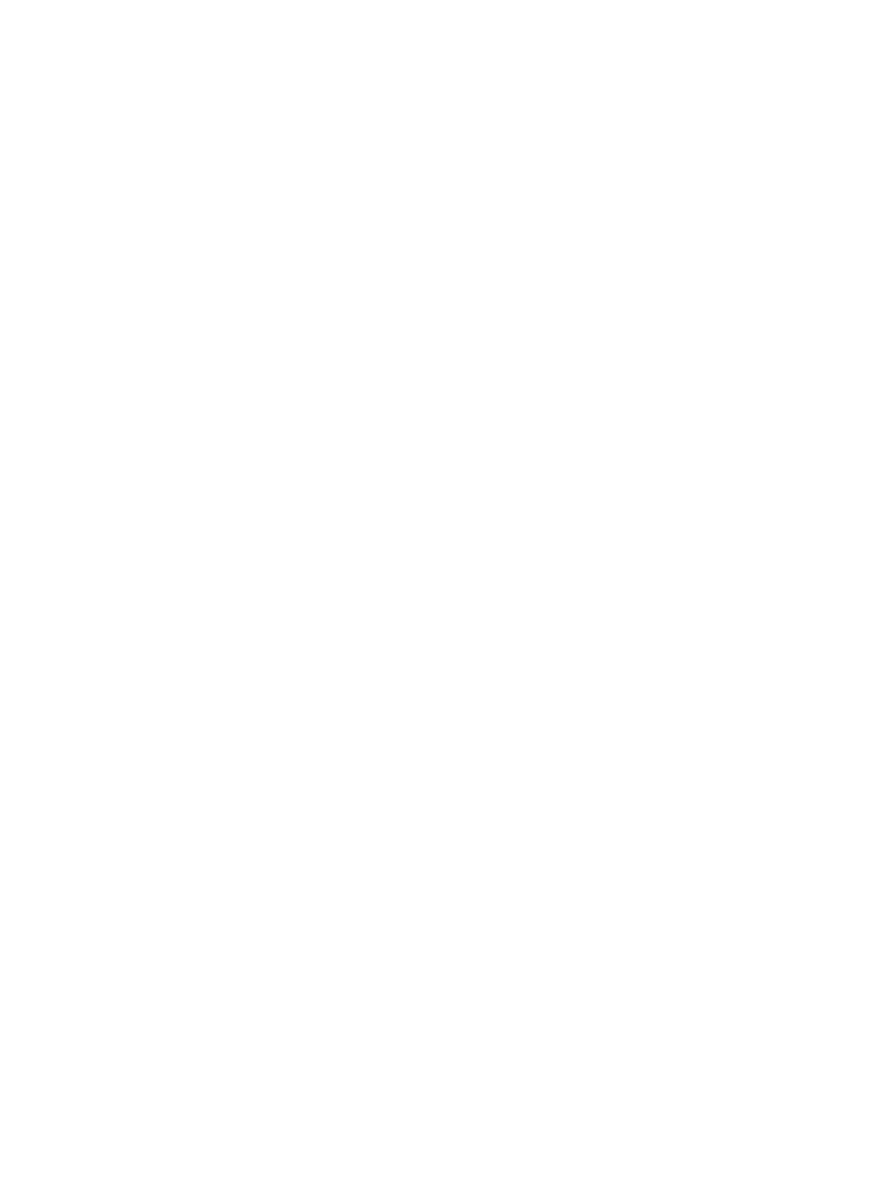

In [11]:
# Reuse the Phase 1 trapezoidal flowchart — same conceptual structure.
from IPython.display import SVG, display
display(SVG(filename='figs/trapezoidal_flow.svg'))


**Phase 2.1 specific notes on the solver flow:**

- The orange "evaluate derivatives" boxes now compute six entries
  instead of four — but each one is still a closed-form expression
  of the state vector and inputs.  No inner Newton.
- The green "update state" boxes apply the trapezoidal rule to all
  six entries simultaneously.  Same averaging formula, same
  second-order accuracy.
- The corrector convergence tolerance is unchanged
  (`max |Δx| < 1e-6`); the number of iterations to hit it goes up
  because `Efd` now lives inside the loop.
- During the fault the corrector iteration count temporarily jumps
  even higher (we saw mean 3.1 / max 6 in §7's run vs flat-line's
  1.0).  That's expected — the algebraic problem is harder when
  `|V_t|` is collapsing and the AVR is slamming `Efd` to the
  ceiling.

**What does *not* change**:

- The frame bridge (`E'_q − j E'_d` rotated by `δ`) is still where
  machine dq meets system DQ.  The AVR adds no rotation logic.
- The Norton-augmented Ybus trick is still valid.  The AVR
  contributes zero current to the network, so the Y_aug matrix is
  unchanged.
- The flat-line correctness floor still holds (§5 above), the deep-
  fault Q-rise rule still holds, the LV ride-through rule still
  holds.


## 10. What's coming in Phase 2.2 (PSS1A)

The CCT lift from the AVR on this case is ~52 ms (~19 %) — meaningful, but bought at a real cost.
The other thing the AVR did in §6's voltage step is *introduce a
new slow mode* into the closed loop: `T'_d0` is now part of an
active feedback loop, and high-gain proportional regulators on
slow plants like that have a tendency to *destabilise* the inter-
machine oscillation mode (~1 Hz on a typical bulk-AC system).

That's why every real-world generator with an AVR also has a
**Power System Stabiliser** (PSS).  The PSS senses speed deviation
$\Delta \omega$, runs it through a washout + lead-lag chain, and
injects the result as `V_pss` into the AVR summer — adding
*electrical damping* to the swing mode.

Phase 2.2 wires `smib/models/pss1a.py` into the GENROU + ST1A loop
and demonstrates the textbook PSS-off / PSS-on damping comparison
on a single-line fault.  Same notebook structure as this one, with
a third headline plot showing the rotor-angle envelope decay rate.

Phase 2.3 finally closes the loop with the **governor** (TGOV1),
which adjusts mechanical power `P_m` in response to frequency
deviation.  At that point all four pillars of the classical machine
stack are in place.
